# Notebook 05 — Interfaz de clasificación de cuentas
**Persona C — Grupo N.° 4 · CCPG1044 Inteligencia Artificial**

Este notebook cierra el tercer sub-problema del proyecto: **aplicación del resultado**. No entrena
nada; carga los cinco modelos ya entrenados y permite clasificar una cuenta nueva a partir de sus
17 atributos públicos, mostrando el veredicto y las variables que más influyeron en él.

Implementa los tres casos de uso definidos en la Tarea #3:

| Caso de uso | Dónde se implementa |
|---|---|
| **UC1** — Cargar datos de la cuenta, con validación y flujo alterno de corrección | Sección 4 |
| **UC2** — Clasificar la cuenta, indicando menor confianza si las señales no son concluyentes | Sección 5 |
| **UC3** — Visualizar el resultado y las variables influyentes, con detalle ampliado | Secciones 6 y 7 |

---
## Modelo principal: Gradient Boosting

La comparación del Notebook 04 dejó a Random Forest y Gradient Boosting separados por 0.0001 de F1,
con una prueba de McNemar de p = 0.451: **empate estadístico**. Cuando dos modelos empatan, la
Sección 9 de ese notebook establece que la elección se decide por interpretabilidad y no por el
número más alto de la tabla. Gradient Boosting gana en los tres criterios que importan aquí:

- **Menos falsos negativos** (931 frente a 998), que según el objetivo del proyecto son el error más
  costoso: cuentas falsas aprobadas como auténticas.
- **Mayor recall sobre la clase falsa** (0.8535 frente a 0.8430) y AUC marginalmente superior.
- **Explicación individual instantánea**: SHAP sobre este modelo resuelve una cuenta en centésimas de
  segundo, mientras que sobre Random Forest tarda unas 25 veces más. Sin eso, el UC3 no sería viable
  en una interfaz interactiva.

Aun así, la interfaz **consulta los cinco modelos** y muestra el veredicto de cada uno: el consenso
entre algoritmos distintos es información útil para el analista y evidencia el trabajo completo del
grupo.

In [1]:
pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga de la partición, los modelos y el preprocesamiento

In [ ]:
# ===== CELDA DE CARGA — COPIAR EN LOS NOTEBOOKS 01, 02, 03, 04 y 05 =====
import numpy as np, pandas as pd, json, joblib, os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA = '/content/drive/MyDrive/Proyecto_IA_Grupo4'
except Exception:
    # Ejecutando localmente: ajuste esta ruta a la carpeta compartida del grupo
    CARPETA = os.path.expanduser(r'c:/Users/JDC/Universidad/File_General/NIVEL_400-I/Proy_IA_G4')

RUTA_SPLIT = f'{CARPETA}/split'
RUTA_RES   = f'{CARPETA}/resultados'
RUTA_FIGS  = f'{CARPETA}/figuras'
os.makedirs(RUTA_RES, exist_ok=True); os.makedirs(RUTA_FIGS, exist_ok=True)

if not os.path.exists(f'{RUTA_SPLIT}/particion.npz'):
    raise FileNotFoundError(
        f'No se encuentra {RUTA_SPLIT}/particion.npz. '
        'Ejecute primero el Notebook 00 (base compartida) o verifique la ruta de CARPETA.'
    )

datos = np.load(f'{RUTA_SPLIT}/particion.npz', allow_pickle=True)
VARIABLES = list(datos['variables'])

X_train      = pd.DataFrame(datos['X_train'],     columns=VARIABLES)
X_test       = pd.DataFrame(datos['X_test'],      columns=VARIABLES)
X_train_esc  = pd.DataFrame(datos['X_train_esc'], columns=VARIABLES)
X_test_esc   = pd.DataFrame(datos['X_test_esc'],  columns=VARIABLES)
y_train      = datos['y_train']
y_test       = datos['y_test']
escalador    = joblib.load(f'{RUTA_SPLIT}/escalador.joblib')

SEMILLA = 42
print('Carpeta de trabajo:', CARPETA)
print('Train:', X_train.shape, '| Test:', X_test.shape)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

# Variables a las que el Notebook 00 aplico log(1+x) antes de estandarizar.
# Se leen del archivo de metadatos para no repetir la lista a mano y arriesgar
# que la interfaz preprocese distinto a como se entrenaron los modelos.
try:
    with open(f'{RUTA_SPLIT}/metadatos.json', encoding='utf-8') as fh:
        METADATOS = json.load(fh)
    VARS_LOG = METADATOS['variables_log1p']
except Exception:
    VARS_LOG = ['pos','flw','flg','bl','cl','erl','erc','hc','pr','fo','pi']
    METADATOS = {}

print('Variables con transformacion logaritmica:', VARS_LOG)

Variables con transformacion logaritmica: ['pos', 'flw', 'flg', 'bl', 'cl', 'erl', 'erc', 'hc', 'pr', 'fo', 'pi']


In [5]:
DICCIONARIO = {
 'pos': 'Numero de publicaciones',
 'flw': 'Numero de seguidores (followers)',
 'flg': 'Numero de cuentas seguidas (following)',
 'bl' : 'Longitud de la biografia (caracteres)',
 'pic': 'Tiene foto de perfil (1 = si, 0 = no)',
 'lin': 'Tiene enlace externo en la biografia (1 = si, 0 = no)',
 'cl' : 'Longitud promedio del texto de las publicaciones',
 'cz' : 'Proporcion de publicaciones sin texto (0 a 1)',
 'ni' : 'Proporcion de publicaciones que no son imagen (0 a 1)',
 'erl': 'Tasa de engagement por likes',
 'erc': 'Tasa de engagement por comentarios',
 'lt' : 'Proporcion de publicaciones con ubicacion (0 a 1)',
 'hc' : 'Promedio de hashtags por publicacion',
 'pr' : 'Promedio de cuentas etiquetadas por publicacion',
 'fo' : 'Promedio de menciones por publicacion',
 'cs' : 'Similitud promedio entre los textos de las publicaciones (0 a 1)',
 'pi' : 'Intervalo promedio entre publicaciones (horas)',
}

# Reglas de validacion del UC1: tipo y rango esperado de cada atributo
REGLAS = {v: {'tipo': 'entero' if v in ['pos','flw','flg','bl','pic','lin'] else 'decimal',
              'min': 0.0,
              'max': 1.0 if v in ['pic','lin','cz','ni','lt','cs'] else None}
          for v in VARIABLES}

# Referencia del conjunto de entrenamiento, para dar contexto al analista
REFERENCIA = pd.DataFrame({
    'mediana_general': X_train.median(),
    'mediana_autenticas': X_train[y_train == 0].median(),
    'mediana_falsas': X_train[y_train == 1].median(),
}).round(3)
display(REFERENCIA)

,mediana_general,mediana_autenticas,mediana_falsas
pos,31.000,39.000,22.000
flw,348.000,434.000,269.000
flg,995.000,643.000,2100.000
bl,33.000,62.000,2.000
pic,1.000,1.000,1.000
lin,0.000,0.000,0.000
cl,49.000,74.000,23.000
cz,0.056,0.000,0.167
ni,0.083,0.167,0.000
erl,9.710,13.150,5.500


### Carga de los cinco modelos entrenados

Cada modelo trae consigo su umbral de decisión optimizado y la indicación de si espera los datos
escalados o en unidades originales. Ese dato es crítico: pasarle datos sin escalar a la regresión
logística o a la red produciría predicciones sin sentido, sin que nada falle visiblemente.

In [6]:
MODELOS = {}

ARCHIVOS = [
    ('gradient_boosting',   'modelo_gradient_boosting.joblib',   'Gradient Boosting'),
    ('random_forest',       'modelo_random_forest.joblib',       'Random Forest'),
    ('arbol_decision',      'modelo_arbol_decision.joblib',      'Arbol de Decision'),
    ('regresion_logistica', 'modelo_regresion_logistica.joblib', 'Regresion Logistica'),
]

for clave, archivo, nombre in ARCHIVOS:
    ruta = f'{RUTA_RES}/{archivo}'
    if os.path.exists(ruta):
        paquete = joblib.load(ruta)
        MODELOS[clave] = {'nombre': nombre, 'modelo': paquete['modelo'],
                          'umbral': paquete['umbral'], 'escalado': paquete['usa_escalado'],
                          'tipo': 'sklearn'}
    else:
        print(f'AVISO: no se encontro {archivo} — ese modelo no aparecera en la interfaz.')

# La red neuronal se guarda en formato propio de Keras
ruta_mlp = f'{RUTA_RES}/modelo_mlp.keras'
ruta_meta = f'{RUTA_RES}/modelo_mlp_meta.joblib'
if os.path.exists(ruta_mlp) and os.path.exists(ruta_meta):
    try:
        os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
        from tensorflow import keras
        meta = joblib.load(ruta_meta)
        MODELOS['red_neuronal_mlp'] = {'nombre': 'Red Neuronal MLP',
                                       'modelo': keras.models.load_model(ruta_mlp),
                                       'umbral': meta['umbral'], 'escalado': meta['usa_escalado'],
                                       'tipo': 'keras'}
    except Exception as e:
        print(f'AVISO: la red neuronal no pudo cargarse ({type(e).__name__}). '
              'La interfaz funcionara con los otros modelos.')
else:
    print('AVISO: faltan los archivos de la red neuronal.')

MODELO_PRINCIPAL = 'gradient_boosting' if 'gradient_boosting' in MODELOS else list(MODELOS)[0]

print(f'\nModelos cargados: {len(MODELOS)}')
for k, v in MODELOS.items():
    marca = '  <-- principal' if k == MODELO_PRINCIPAL else ''
    print(f"  - {v['nombre']}: umbral {v['umbral']:.4f}, "
          f"{'datos escalados' if v['escalado'] else 'datos originales'}{marca}")


Modelos cargados: 5
  - Gradient Boosting: umbral 0.4929, datos originales  <-- principal
  - Random Forest: umbral 0.5233, datos originales
  - Arbol de Decision: umbral 0.4684, datos originales
  - Regresion Logistica: umbral 0.4706, datos escalados
  - Red Neuronal MLP: umbral 0.4586, datos escalados


## 2. Preprocesamiento idéntico al del entrenamiento

Este es el punto donde más fácilmente se rompe un sistema de clasificación en producción: si la
interfaz transforma los datos de una forma distinta a como se entrenó el modelo, las predicciones
salen mal sin que nada arroje un error.

La función siguiente replica exactamente los dos pasos del Notebook 00 —`log(1+x)` sobre las
variables sesgadas y luego el `StandardScaler` ya ajustado— reutilizando el escalador guardado, no
uno nuevo. La celda de verificación comprueba que reproduce los valores del conjunto de prueba.

In [7]:
def preprocesar(cuenta):
    """Convierte un diccionario de atributos en las dos matrices que esperan los modelos."""
    fila = pd.DataFrame([[float(cuenta[v]) for v in VARIABLES]], columns=VARIABLES)
    fila_log = fila.copy()
    fila_log[VARS_LOG] = np.log1p(fila_log[VARS_LOG])
    fila_esc = pd.DataFrame(escalador.transform(fila_log), columns=VARIABLES)
    return fila, fila_esc


# Verificacion: preprocesar una cuenta del conjunto de prueba debe reproducir su version escalada
_i = 0
_orig, _esc = preprocesar(X_test.iloc[_i].to_dict())
_error = np.abs(_esc.values - X_test_esc.iloc[_i].values).max()
print(f'Diferencia maxima frente al preprocesamiento del Notebook 00: {_error:.10f}')
assert _error < 1e-8, 'El preprocesamiento de la interfaz NO coincide con el del entrenamiento.'
print('Verificacion superada: la interfaz preprocesa igual que el entrenamiento.')

Diferencia maxima frente al preprocesamiento del Notebook 00: 0.0000000000
Verificacion superada: la interfaz preprocesa igual que el entrenamiento.


## 3. Explicador SHAP del modelo principal

Se construye una sola vez y queda en memoria. Explicar una cuenta después toma centésimas de segundo,
que es lo que hace viable el UC3 dentro de una interfaz interactiva.

In [8]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

import time
t0 = time.time()
EXPLICADOR = shap.TreeExplainer(MODELOS[MODELO_PRINCIPAL]['modelo'])
print(f'Explicador construido en {time.time()-t0:.2f} s sobre {MODELOS[MODELO_PRINCIPAL]["nombre"]}')

t0 = time.time()
_ = EXPLICADOR.shap_values(X_test.iloc[[0]], check_additivity=False)
print(f'Explicacion de una cuenta: {time.time()-t0:.3f} s')

Explicador construido en 0.00 s sobre Gradient Boosting
Explicacion de una cuenta: 0.001 s


## 4. UC1 — Validación de los datos de la cuenta

El flujo básico del UC1 verifica que los valores tengan el tipo y rango esperado; el flujo alterno
detecta un valor faltante, fuera de rango o de tipo incorrecto y solicita corregirlo antes de
continuar. La función devuelve dos listas separadas:

- **Errores**: impiden clasificar. Falta un atributo, no es numérico, es negativo o una proporción
  supera 1.
- **Advertencias**: no impiden clasificar, pero avisan de valores inusuales que conviene revisar
  antes de confiar en el resultado.

In [9]:
def validar(cuenta):
    """UC1: valida tipo y rango de los 17 atributos. Devuelve (errores, advertencias)."""
    errores, advertencias = [], []

    for v in VARIABLES:
        if v not in cuenta or cuenta[v] is None or cuenta[v] == '':
            errores.append(f'{v} ({DICCIONARIO[v]}): falta el valor.')
            continue
        try:
            valor = float(cuenta[v])
        except (TypeError, ValueError):
            errores.append(f'{v}: "{cuenta[v]}" no es un numero.')
            continue
        if not np.isfinite(valor):
            errores.append(f'{v}: el valor no es finito.')
            continue

        regla = REGLAS[v]
        if valor < regla['min']:
            errores.append(f'{v}: no puede ser negativo (recibido {valor}).')
        if regla['max'] is not None and valor > regla['max']:
            errores.append(f'{v}: debe estar entre 0 y 1 (recibido {valor}).')
        if regla['tipo'] == 'entero' and valor != int(valor):
            advertencias.append(f'{v}: se esperaba un entero, se recibio {valor}.')

    if not errores:
        # Coherencias propias del dominio
        if float(cuenta['pos']) == 0 and float(cuenta['erl']) > 0:
            advertencias.append('La cuenta no tiene publicaciones pero reporta engagement por likes.')
        if float(cuenta['flw']) > 0 and float(cuenta['flg']) / (float(cuenta['flw']) + 1) > 50:
            advertencias.append('Relacion seguidos/seguidores muy alta: revise que los valores no esten invertidos.')
        for v in VARIABLES:
            valor = float(cuenta[v])
            maximo = float(X_train[v].max())
            if valor > maximo:
                advertencias.append(f'{v} = {valor:,.2f} supera el maximo visto en entrenamiento '
                                    f'({maximo:,.2f}); la prediccion es una extrapolacion.')
    return errores, advertencias

# Prueba del flujo alterno con datos deliberadamente incorrectos
cuenta_mala = {v: 0 for v in VARIABLES}
cuenta_mala['flw'] = -50; cuenta_mala['cz'] = 3.2; cuenta_mala['pos'] = 'abc'
del cuenta_mala['erl']
e, a = validar(cuenta_mala)
print('Errores detectados (el sistema solicitaria correccion):')
for x in e: print('  -', x)

Errores detectados (el sistema solicitaria correccion):
  - pos: "abc" no es un numero.
  - flw: no puede ser negativo (recibido -50.0).
  - cz: debe estar entre 0 y 1 (recibido 3.2).
  - erl (Tasa de engagement por likes): falta el valor.


## 5. UC2 — Clasificación con nivel de confianza

El flujo básico devuelve la etiqueta; el flujo alterno contempla el caso en que las señales no son
concluyentes, y ahí el sistema entrega la clasificación indicando un nivel de confianza menor.

La confianza se mide por la distancia entre la probabilidad predicha y el umbral del modelo: una
cuenta con probabilidad 0.51 frente a un umbral de 0.49 está clasificada como falsa, pero apenas.
Se reporta además el **consenso**: cuántos de los cinco modelos coinciden con el veredicto principal.

In [10]:
def probabilidad_modelo(clave, fila, fila_esc):
    info = MODELOS[clave]
    entrada = fila_esc if info['escalado'] else fila
    if info['tipo'] == 'keras':
        return float(info['modelo'].predict(entrada.values, verbose=0).ravel()[0])
    return float(info['modelo'].predict_proba(entrada)[0, 1])


def clasificar(cuenta):
    """UC2: clasifica la cuenta con los cinco modelos y devuelve el resultado completo."""
    errores, advertencias = validar(cuenta)
    if errores:
        return {'valido': False, 'errores': errores, 'advertencias': advertencias}

    fila, fila_esc = preprocesar(cuenta)

    votos = {}
    for clave in MODELOS:
        p = probabilidad_modelo(clave, fila, fila_esc)
        votos[clave] = {'nombre': MODELOS[clave]['nombre'], 'probabilidad': p,
                        'umbral': MODELOS[clave]['umbral'],
                        'etiqueta': 'FALSA' if p >= MODELOS[clave]['umbral'] else 'AUTENTICA'}

    principal = votos[MODELO_PRINCIPAL]
    margen = abs(principal['probabilidad'] - principal['umbral'])
    if margen < 0.10:
        confianza = 'BAJA'
    elif margen < 0.25:
        confianza = 'MEDIA'
    else:
        confianza = 'ALTA'

    n_falsa = sum(1 for v in votos.values() if v['etiqueta'] == 'FALSA')
    de_acuerdo = sum(1 for v in votos.values() if v['etiqueta'] == principal['etiqueta'])

    return {
        'valido': True,
        'errores': [],
        'advertencias': advertencias,
        'etiqueta': principal['etiqueta'],
        'probabilidad': principal['probabilidad'],
        'umbral': principal['umbral'],
        'margen': margen,
        'confianza': confianza,
        'votos': votos,
        'n_votos_falsa': n_falsa,
        'n_modelos': len(votos),
        'consenso': de_acuerdo,
        'fila': fila,
    }

print('Funciones de clasificacion listas.')

Funciones de clasificacion listas.


## 6. UC3 — Explicación de las variables influyentes

Devuelve, para la cuenta consultada, cuánto aportó cada atributo a la decisión y en qué dirección.
El aporte está en unidades de log-odds: positivo empuja hacia "falsa", negativo hacia "auténtica".
Se acompaña de la mediana del conjunto de entrenamiento para cada clase, de modo que el analista vea
no solo que un valor pesó, sino contra qué se está comparando.

In [11]:
def explicar(resultado, top=8):
    """UC3: aportes SHAP de cada variable para la cuenta consultada."""
    fila = resultado['fila']
    valores = EXPLICADOR.shap_values(fila, check_additivity=False)
    valores = np.array(valores)
    if valores.ndim == 3:
        valores = valores[:, :, 1]
    aportes = valores[0]

    tabla = pd.DataFrame({
        'variable': VARIABLES,
        'descripcion': [DICCIONARIO[v] for v in VARIABLES],
        'valor_ingresado': fila.values[0],
        'mediana_autenticas': REFERENCIA['mediana_autenticas'].values,
        'mediana_falsas': REFERENCIA['mediana_falsas'].values,
        'aporte': aportes,
    })
    tabla['empuja_hacia'] = np.where(tabla.aporte > 0, 'FALSA', 'AUTENTICA')
    return tabla.sort_values('aporte', key=abs, ascending=False).head(top).reset_index(drop=True)


def grafico_explicacion(tabla, titulo='Variables que mas influyeron en la decision'):
    d = tabla.sort_values('aporte')
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(d) + 1.5))
    colores = ['#C0504D' if v > 0 else '#4C9F70' for v in d.aporte]
    etiquetas = [f'{r.variable} = {r.valor_ingresado:,.2f}' for r in d.itertuples()]
    ax.barh(etiquetas, d.aporte, color=colores)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Aporte a la decision (rojo: hacia FALSA · verde: hacia AUTENTICA)')
    ax.set_title(titulo)
    plt.tight_layout(); plt.show()

print('Funciones de explicacion listas.')

Funciones de explicacion listas.


## 7. Reporte completo

Junta los tres casos de uso en una sola salida: validación, veredicto con nivel de confianza,
consenso entre los cinco modelos y explicación de las variables influyentes.

In [12]:
def reporte(cuenta, mostrar_grafico=True, detalle_ampliado=False):
    """Ejecuta UC1 + UC2 + UC3 y presenta el resultado al analista."""
    r = clasificar(cuenta)

    if not r['valido']:
        print('=' * 62)
        print('DATOS INVALIDOS — corrija los siguientes puntos y vuelva a intentar')
        print('=' * 62)
        for e in r['errores']:
            print('  X', e)
        return r

    simbolo = 'CUENTA FALSA' if r['etiqueta'] == 'FALSA' else 'CUENTA AUTENTICA'
    print('=' * 62)
    print(f'RESULTADO: {simbolo}')
    print('=' * 62)
    print(f"Probabilidad de ser falsa : {r['probabilidad']:.4f}")
    print(f"Umbral del modelo         : {r['umbral']:.4f}")
    print(f"Nivel de confianza        : {r['confianza']}  (margen {r['margen']:.4f})")
    print(f"Consenso                  : {r['consenso']} de {r['n_modelos']} modelos coinciden")

    if r['confianza'] == 'BAJA':
        print('\n  ! Las senales de esta cuenta no son concluyentes. Se recomienda revision manual.')
    if r['advertencias']:
        print('\n  Advertencias sobre los datos ingresados:')
        for a in r['advertencias']:
            print('   -', a)

    print('\n--- Veredicto de cada modelo ---')
    votos = pd.DataFrame([
        {'modelo': v['nombre'], 'probabilidad': round(v['probabilidad'], 4),
         'umbral': round(v['umbral'], 4), 'clasifica_como': v['etiqueta']}
        for v in r['votos'].values()
    ]).sort_values('probabilidad', ascending=False)
    display(votos)

    print('\n--- Variables que mas influyeron ---')
    tabla = explicar(r, top=17 if detalle_ampliado else 8)
    display(tabla.round(4))
    if mostrar_grafico:
        grafico_explicacion(tabla)
    return r

print('Reporte listo.')

Reporte listo.


## 8. Prueba con cuentas reales del conjunto de prueba

Antes de usar la interfaz conviene comprobarla con cuentas cuya etiqueta real se conoce. Se toman
tres casos: una cuenta falsa clara, una auténtica clara y una de la zona de incertidumbre, que es
justamente el escenario alterno del UC2.

In [13]:
prob_test = np.array([probabilidad_modelo(MODELO_PRINCIPAL,
                                          X_test.iloc[[i]].reset_index(drop=True),
                                          X_test_esc.iloc[[i]].reset_index(drop=True))
                      for i in range(300)])   # muestra de 300 para localizar los ejemplos

u = MODELOS[MODELO_PRINCIPAL]['umbral']
idx_falsa   = int(np.argmax(prob_test))
idx_autentica = int(np.argmin(prob_test))
idx_dudosa  = int(np.argmin(np.abs(prob_test - u)))

print(f'Ejemplo de cuenta falsa   -> indice {idx_falsa}, etiqueta real: '
      f'{"FALSA" if y_test[idx_falsa] == 1 else "AUTENTICA"}')
print(f'Ejemplo de cuenta autentica -> indice {idx_autentica}, etiqueta real: '
      f'{"FALSA" if y_test[idx_autentica] == 1 else "AUTENTICA"}')
print(f'Ejemplo en zona de duda   -> indice {idx_dudosa}, etiqueta real: '
      f'{"FALSA" if y_test[idx_dudosa] == 1 else "AUTENTICA"}')

Ejemplo de cuenta falsa   -> indice 129, etiqueta real: FALSA
Ejemplo de cuenta autentica -> indice 112, etiqueta real: AUTENTICA
Ejemplo en zona de duda   -> indice 149, etiqueta real: FALSA


RESULTADO: CUENTA FALSA
Probabilidad de ser falsa : 0.9996
Umbral del modelo         : 0.4929
Nivel de confianza        : ALTA  (margen 0.5068)
Consenso                  : 5 de 5 modelos coinciden

--- Veredicto de cada modelo ---


,modelo,probabilidad,umbral,clasifica_como
2,Arbol de Decision,1.0000,0.4684,FALSA
4,Red Neuronal MLP,1.0000,0.4586,FALSA
0,Gradient Boosting,0.9996,0.4929,FALSA
1,Random Forest,0.9967,0.5233,FALSA
3,Regresion Logistica,0.9964,0.4706,FALSA



--- Variables que mas influyeron ---


,variable,descripcion,valor_ingresado,mediana_autenticas,mediana_falsas,aporte,empuja_hacia
0,erl,Tasa de engagement por likes,2.70,13.150,5.500,1.5100,FALSA
1,lin,"Tiene enlace externo en la biografia (1 = si, ...",0.00,0.000,0.000,1.3734,FALSA
2,erc,Tasa de engagement por comentarios,0.32,0.690,0.210,1.3659,FALSA
3,pr,Promedio de cuentas etiquetadas por publicacion,0.50,0.000,0.000,1.0113,FALSA
4,cl,Longitud promedio del texto de las publicaciones,1119.00,74.000,23.000,0.8485,FALSA
5,flw,Numero de seguidores (followers),171.00,434.000,269.000,0.3631,FALSA
6,lt,Proporcion de publicaciones con ubicacion (0 a 1),0.00,0.167,0.000,0.2887,FALSA
7,cs,Similitud promedio entre los textos de las pub...,1.00,0.080,0.215,0.1905,FALSA


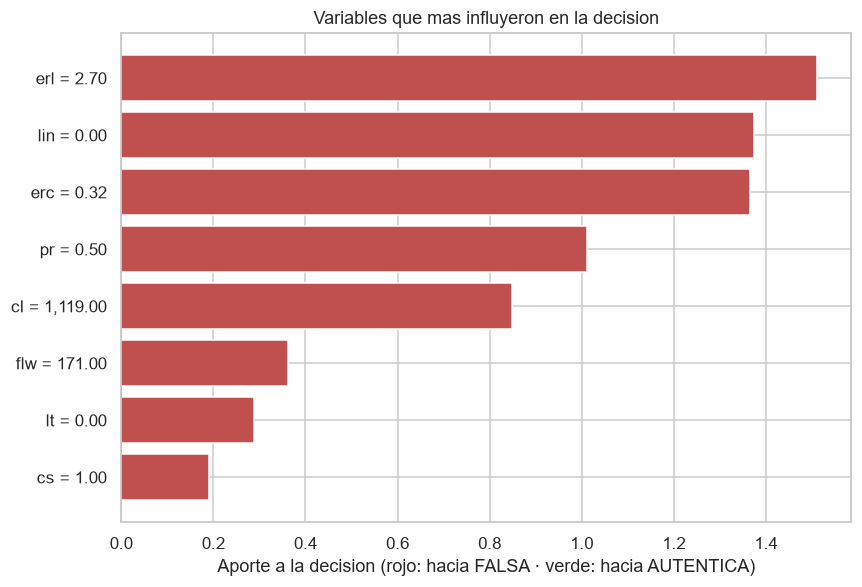

In [14]:
_ = reporte(X_test.iloc[idx_falsa].to_dict())

RESULTADO: CUENTA AUTENTICA
Probabilidad de ser falsa : 0.0074
Umbral del modelo         : 0.4929
Nivel de confianza        : ALTA  (margen 0.4855)
Consenso                  : 5 de 5 modelos coinciden

--- Veredicto de cada modelo ---


,modelo,probabilidad,umbral,clasifica_como
2,Arbol de Decision,0.0083,0.4684,AUTENTICA
0,Gradient Boosting,0.0074,0.4929,AUTENTICA
3,Regresion Logistica,0.0029,0.4706,AUTENTICA
4,Red Neuronal MLP,0.0007,0.4586,AUTENTICA
1,Random Forest,0.0000,0.5233,AUTENTICA



--- Variables que mas influyeron ---


,variable,descripcion,valor_ingresado,mediana_autenticas,mediana_falsas,aporte,empuja_hacia
0,flg,Numero de cuentas seguidas (following),297.000,643.000,2100.000,-1.1098,AUTENTICA
1,erl,Tasa de engagement por likes,20.100,13.150,5.500,-1.0653,AUTENTICA
2,lin,"Tiene enlace externo en la biografia (1 = si, ...",1.000,0.000,0.000,-0.9796,AUTENTICA
3,erc,Tasa de engagement por comentarios,0.910,0.690,0.210,-0.7507,AUTENTICA
4,flw,Numero de seguidores (followers),509.000,434.000,269.000,-0.4823,AUTENTICA
5,lt,Proporcion de publicaciones con ubicacion (0 a 1),0.944,0.167,0.000,-0.4479,AUTENTICA
6,pos,Numero de publicaciones,355.000,39.000,22.000,-0.2503,AUTENTICA
7,cz,Proporcion de publicaciones sin texto (0 a 1),0.000,0.000,0.167,-0.2045,AUTENTICA


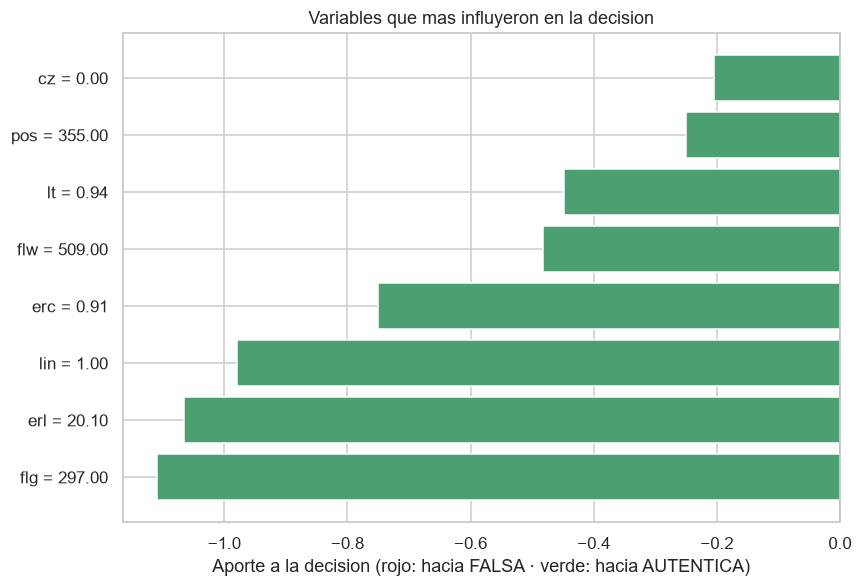

In [15]:
_ = reporte(X_test.iloc[idx_autentica].to_dict())

RESULTADO: CUENTA FALSA
Probabilidad de ser falsa : 0.4989
Umbral del modelo         : 0.4929
Nivel de confianza        : BAJA  (margen 0.0060)
Consenso                  : 3 de 5 modelos coinciden

  ! Las senales de esta cuenta no son concluyentes. Se recomienda revision manual.

--- Veredicto de cada modelo ---


,modelo,probabilidad,umbral,clasifica_como
3,Regresion Logistica,0.8549,0.4706,FALSA
0,Gradient Boosting,0.4989,0.4929,FALSA
4,Red Neuronal MLP,0.4942,0.4586,FALSA
1,Random Forest,0.4367,0.5233,AUTENTICA
2,Arbol de Decision,0.1905,0.4684,AUTENTICA



--- Variables que mas influyeron ---


,variable,descripcion,valor_ingresado,mediana_autenticas,mediana_falsas,aporte,empuja_hacia
0,lin,"Tiene enlace externo en la biografia (1 = si, ...",1.000,0.00,0.000,-2.6956,AUTENTICA
1,flw,Numero de seguidores (followers),4200.000,434.00,269.000,-1.5343,AUTENTICA
2,flg,Numero de cuentas seguidas (following),7100.000,643.00,2100.000,1.3497,FALSA
3,erl,Tasa de engagement por likes,0.340,13.15,5.500,0.7868,FALSA
4,erc,Tasa de engagement por comentarios,0.010,0.69,0.210,0.5765,FALSA
5,bl,Longitud de la biografia (caracteres),117.000,62.00,2.000,-0.3769,AUTENTICA
6,cz,Proporcion de publicaciones sin texto (0 a 1),0.500,0.00,0.167,0.3165,FALSA
7,pr,Promedio de cuentas etiquetadas por publicacion,0.111,0.00,0.000,0.2893,FALSA


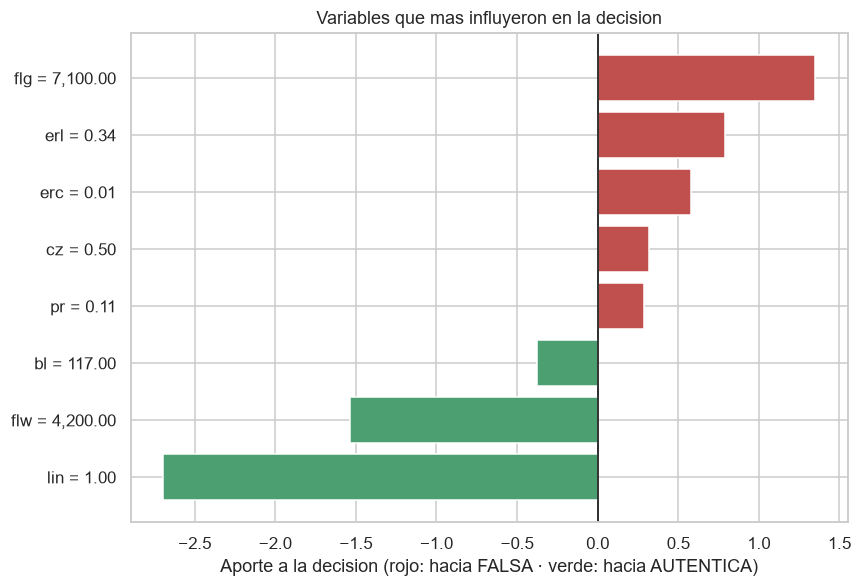

In [16]:
# Escenario alterno del UC2: senales no concluyentes
_ = reporte(X_test.iloc[idx_dudosa].to_dict())

## 9. Interfaz interactiva

Formulario con los 17 atributos. Los botones permiten clasificar la cuenta, cargar una cuenta real
del conjunto de prueba para probar rápido, y limpiar el formulario.

Si los controles no se muestran en VS Code, hay que instalar la extensión de Jupyter y reiniciar el
kernel; en Colab funcionan sin configuración adicional. En cualquier caso, la Sección 8 y la
Sección 10 permiten usar el sistema sin interfaz gráfica.

In [17]:
import ipywidgets as widgets
from IPython.display import display as mostrar, clear_output

campos = {}
for v in VARIABLES:
    campos[v] = widgets.FloatText(
        value=float(X_train[v].median()),
        description=str(v),
        style={'description_width': '45px'},
        layout=widgets.Layout(width='230px'),
    )

ayuda = widgets.HTML('<b>Atributos publicos de la cuenta</b><br>'
                     '<span style="font-size:11px">Los valores iniciales son la mediana del '
                     'conjunto de entrenamiento. Pase el cursor sobre cada campo para ver su '
                     'descripcion en la tabla de la Seccion 1.</span>')

filas = [widgets.HBox([campos[v] for v in VARIABLES[i:i+4]]) for i in range(0, len(VARIABLES), 4)]

boton_clasificar = widgets.Button(description='Clasificar cuenta', button_style='primary',
                                  icon='search', layout=widgets.Layout(width='180px'))
boton_ejemplo = widgets.Button(description='Cargar cuenta real', button_style='info',
                               icon='random', layout=widgets.Layout(width='180px'))
boton_limpiar = widgets.Button(description='Limpiar', layout=widgets.Layout(width='120px'))
detalle = widgets.Checkbox(value=False, description='Detalle ampliado (17 variables)', indent=False)
salida = widgets.Output()


def al_clasificar(_):
    with salida:
        clear_output()
        cuenta = {v: campos[v].value for v in VARIABLES}
        reporte(cuenta, detalle_ampliado=detalle.value)


def al_cargar_ejemplo(_):
    i = int(np.random.default_rng().integers(0, len(X_test)))
    for v in VARIABLES:
        campos[v].value = float(X_test.iloc[i][v])
    with salida:
        clear_output()
        real = 'FALSA' if y_test[i] == 1 else 'AUTENTICA'
        print(f'Cuenta #{i} del conjunto de prueba cargada en el formulario.')
        print(f'Etiqueta real (solo para verificacion): {real}')
        print('Presione "Clasificar cuenta" para ver que responde el sistema.')


def al_limpiar(_):
    for v in VARIABLES:
        campos[v].value = 0.0
    with salida:
        clear_output()


boton_clasificar.on_click(al_clasificar)
boton_ejemplo.on_click(al_cargar_ejemplo)
boton_limpiar.on_click(al_limpiar)

mostrar(widgets.VBox([
    ayuda,
    *filas,
    widgets.HBox([boton_clasificar, boton_ejemplo, boton_limpiar, detalle]),
    salida,
]))

## 10. Clasificación por lotes

Extensión práctica del UC1: en lugar de una cuenta a la vez, procesa un archivo CSV con muchas
cuentas y devuelve las predicciones de los cinco modelos. Es el formato en que una agencia
auditaría una lista de perfiles.

In [ ]:
def clasificar_lote(df_cuentas):
    """Clasifica un DataFrame con las 17 columnas de atributos."""
    faltan = [v for v in VARIABLES if v not in df_cuentas.columns]
    if faltan:
        raise ValueError(f'Faltan columnas en el archivo: {faltan}')

    fila = df_cuentas[VARIABLES].astype(float).reset_index(drop=True)
    fila_log = fila.copy()
    fila_log[VARS_LOG] = np.log1p(fila_log[VARS_LOG])
    fila_esc = pd.DataFrame(escalador.transform(fila_log), columns=VARIABLES)

    salida_df = fila.copy()
    for clave, info in MODELOS.items():
        entrada = fila_esc if info['escalado'] else fila
        if info['tipo'] == 'keras':
            p = info['modelo'].predict(entrada.values, verbose=0).ravel()
        else:
            p = info['modelo'].predict_proba(entrada)[:, 1]
        salida_df[f'prob_{clave}'] = np.round(p, 4)
        salida_df[f'clase_{clave}'] = np.where(p >= info['umbral'], 'FALSA', 'AUTENTICA')

    columnas_clase = [f'clase_{k}' for k in MODELOS]
    salida_df['votos_falsa'] = (salida_df[columnas_clase] == 'FALSA').sum(axis=1)
    salida_df['veredicto'] = salida_df[f'clase_{MODELO_PRINCIPAL}']
    return salida_df


# Demostracion con 10 cuentas reales del conjunto de prueba
demo = clasificar_lote(X_test.head(10))
display(demo[[f'prob_{MODELO_PRINCIPAL}', 'veredicto', 'votos_falsa']].round(4))
print('Etiquetas reales de esas 10 cuentas:',
      ['FALSA' if v == 1 else 'AUTENTICA' for v in y_test[:10]])

demo.to_csv(f'{RUTA_RES}/ejemplo_clasificacion_lote.csv', index=False)
print(f'\nEjemplo guardado en {RUTA_RES}/ejemplo_clasificacion_lote.csv')

---
## Checklist de entrega — Notebook 05

- [ ] Verificación de preprocesamiento superada (la interfaz transforma igual que el entrenamiento).
- [ ] Los cinco modelos cargan correctamente con sus umbrales.
- [ ] Ejemplo de flujo alterno del UC1: datos inválidos y mensajes de corrección.
- [ ] Ejemplo de cuenta falsa, cuenta auténtica y cuenta en zona de incertidumbre (UC2).
- [ ] Gráfico de variables influyentes de al menos una cuenta (UC3).
- [ ] Capturas de la interfaz en funcionamiento para el informe y la sustentación.
- [ ] Justificación escrita de por qué Gradient Boosting es el modelo principal, apoyada en la
      prueba de McNemar y en el conteo de falsos negativos del Notebook 04.

### Para la sustentación

La demostración más convincente es cargar una cuenta real con el botón, clasificarla y contrastar el
resultado con su etiqueta verdadera, mostrando la explicación de variables. Conviene tener preparada
también una cuenta de la zona de incertidumbre: enseña que el sistema reconoce sus propios límites en
lugar de dar un veredicto tajante siempre, que es lo que el escenario alterno del UC2 anticipó desde
la Tarea #3.

### Limitación que conviene declarar

Los modelos se entrenaron con el conjunto de Purba et al. (2020). Una cuenta con valores muy por
encima de los máximos vistos en entrenamiento cae fuera del rango aprendido y su predicción es una
extrapolación; por eso la validación del UC1 emite una advertencia explícita en ese caso. Es la misma
limitación reconocida en la Sección 7 de la Tarea #4 sobre la vigencia del conjunto de datos.